In [1]:
from __future__ import annotations

import contextlib
import ctypes
import gc
import hashlib
import itertools
import json
import logging
import os

from collections.abc import Iterable
from dataclasses import dataclass, replace
from pathlib import Path
from typing import TYPE_CHECKING, Any, cast

import numpy as np
import torch
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from tqdm import tqdm

from qqe.backend import PennylaneBackend, QuimbBackend
from qqe.circuit.families import (
    CliffordBrickwork,
)

# Keep this import path only if it is the correct one in your project.
# If your real function lives in qqe.circuit.matrix_factory, switch it there.
from qqe.circuit.gates import clifford_recipe_unitary, gate_unitary
from qqe.circuit.patterns import TdopingRules, brickwork_pattern, to_qasm
from qqe.circuit.spec import CircuitSpec, GateSpec
from qqe.experiments.core import ExperimentConfig, run_experiment
from qqe.GNN.encoder import eigenvalue_phase_histogram_features, qasm_to_pyg_graph
from qqe.properties.compute import PropertyRequest
from qqe.rng.seeds import gate_seed
from qqe.states.types import BackendConfig
from qqe.utils import FileCache

if TYPE_CHECKING:
    from collections.abc import Generator

    from qqe.circuit.spec import GateSpec


### Haar

In [2]:
@dataclass(frozen=True)
class HaarBrickwork:
    """Haar random circuit family with brickwork pattern.

    Attributes:
        name: The name of the circuit family.
    """

    name: str = "haar"

    def make_spec(
        self,
        n_qubits: int,
        n_layers: int,
        d: int,
        seed: int,
        *,
        connectivity: str = "line",
        pattern: str = "brickwork",
        **kwargs: Any,
    ) -> CircuitSpec:
        params = dict(kwargs)

        spec = CircuitSpec(
            n_qubits=int(n_qubits),
            n_layers=int(n_layers),
            d=int(d),
            global_seed=int(seed),
            family=self.name,
            connectivity=connectivity,
            pattern=pattern,
            params=params,
        )
        return replace(spec, gates=tuple(self.gates(spec)))

    def gates(self, spec: CircuitSpec) -> Generator[GateSpec]:
        gate_probability = float(spec.params.get("gate_probability", 1.0))
        haar_strength = float(spec.params.get("haar_strength", 1.0))
        haar_mode = str(spec.params.get("haar_mode", "full_haar"))

        for layer in range(spec.n_layers):
            pairs = brickwork_pattern(spec.n_qubits, layer, connectivity=spec.connectivity)

            for slot, (a, b) in enumerate(pairs):
                s = gate_seed(
                    spec.global_seed,
                    layer=layer,
                    slot=slot,
                    wires=(a, b),
                    kind="haar",
                )
                rng = np.random.default_rng(s)
                if rng.random() > gate_probability:
                    yield GateSpec(
                        kind="I",
                        wires=(int(a),),
                        d=spec.d,
                        seed=s,
                        tags=("layer", f"L{layer}", "haar_skipped_identity", f"wire_{a}"),
                        params=(),
                    )
                    yield GateSpec(
                        kind="I",
                        wires=(int(b),),
                        d=spec.d,
                        seed=s,
                        tags=("layer", f"L{layer}", "haar_skipped_identity", f"wire_{b}"),
                        params=(),
                    )
                    continue

                yield GateSpec(
                    kind="haar",
                    wires=(a, b),
                    d=spec.d,
                    seed=s,
                    tags=("layer", f"L{layer}", "haar"),
                    params=(s, float(haar_strength), haar_mode),
                )


### Quansistor

In [3]:
def quansistor_blocks(n_qubits: int, n_layer: int) -> list[tuple[int, int, int, int]]:
    start = (n_layer % 2) * 2  # shift by 2 wires each odd layer
    blocks: list[tuple[int, int, int, int]] = []
    for i in range(start, n_qubits - 3, 4):
        blocks.append((i, i + 1, i + 2, i + 3))
    return blocks

def leftover_pairs(n_qubits: int, used: set[int], connectivity: str) -> list[tuple[int, int]]:
    left = [i for i in range(n_qubits) if i not in used]
    leftover = set(left)

    pairs: list[tuple[int, int]] = []
    used = set()

    for i in range(n_qubits - 1):
        a, b = i, i + 1
        if a in leftover and b in leftover and a not in used and b not in used:
            pairs.append((a, b))
            used.update((a, b))
    if connectivity in ("loop", "ring"):
        a, b = n_qubits - 1, 0
        if a in leftover and b in leftover and a not in used and b not in used:
            pairs.append((a, b))
            used.update((a, b))
    return pairs

def kv(**kwargs) -> tuple[str, ...]:
    # deterministic ordering
    return tuple(f"{k}={v}" for k, v in sorted(kwargs.items()))

def _axis_from_seed(seed: int) -> str:
    # deterministic, reproducible across runs
    rng = np.random.default_rng(seed)
    return "X" if rng.integers(0, 2) == 0 else "Y"

_BLOCK_STEPS = (
    (0, 1),  # q0 q1
    (2, 3),  # q2 q3
    (1, 2),  # q1 q2
    (0, 1),  # q0 q1
    (2, 3),  # q2 q3
)

@dataclass(frozen=True)
class QuansistorBrickwork:
    name: str = "quansistor"

    def make_spec(
        self,
        n_qubits: int,
        n_layers: int,
        d: int,
        seed: int,
        *,
        connectivity: str = "line",
        pattern: str = "brickwork",
        **kwargs: Any,
    ) -> CircuitSpec:
        params = dict(kwargs)
        spec = CircuitSpec(
            n_qubits=n_qubits,
            n_layers=n_layers,
            d=d,
            global_seed=seed,
            family=self.name,
            connectivity=connectivity,
            pattern=pattern,
            params=params,
        )
        return replace(spec, gates=tuple(self.gates(spec)))
    def sample_quansistor_params(
            self,
            rng: np.random.Generator,
            param_regime: str,
            param_scale: float | None = None,
        ) -> tuple[float, float, float]:
            if param_regime == "identity_like":
                sigma = 0.02 if param_scale is None else float(param_scale)
                a, b, g = rng.normal(0.0, sigma, 3)

            elif param_regime == "weak":
                sigma = 0.20 if param_scale is None else float(param_scale)
                a, b, g = rng.normal(0.0, sigma, 3)

            elif param_regime == "moderate":
                sigma = 0.75 if param_scale is None else float(param_scale)
                a, b, g = rng.normal(0.0, sigma, 3)

            elif param_regime == "structured_equal_ab":
                scale = np.pi if param_scale is None else float(param_scale) * np.pi
                base = rng.uniform(-scale, scale)
                g = rng.uniform(-0.25, 0.25)
                a, b = base, base

            elif param_regime == "structured_opposite_ab":
                scale = np.pi if param_scale is None else float(param_scale) * np.pi
                base = rng.uniform(-scale, scale)
                g = rng.uniform(-0.25, 0.25)
                a, b = base, -base

            elif param_regime == "generic_uniform":
                a, b, g = rng.uniform(-np.pi, np.pi, 3)

            else:
                raise ValueError(f"Unknown param_regime={param_regime}")

            return float(a), float(b), float(g)

    def gates(self, spec: CircuitSpec) -> Iterable[GateSpec]:
        if spec.pattern == "custom":
            for layer in range(spec.n_layers):
                blocks = quansistor_blocks(spec.n_qubits, layer)
                used: set[int] = set()

                # ---- 4-qubit blocks -> 5 two-qubit gates each
                for block_idx, (q0, q1, q2, q3) in enumerate(blocks):
                    used.update((q0, q1, q2, q3))

                    # One seed namespace per block (so 5 gates share a single RNG stream conceptually)
                    # We derive per-step seeds deterministically from that block identity.
                    block_seed = gate_seed(
                        spec.global_seed,
                        kind="quansistor_block",
                        layer=layer,
                        slot=block_idx,
                        wires=(q0, q1, q2, q3),
                        ordered_wires=True,
                    )

                    # Emit the 5 sequential 2-qubit quansistor gates
                    wires4 = (q0, q1, q2, q3)
                    for step_idx, (i, j) in enumerate(_BLOCK_STEPS):
                        a, b = wires4[i], wires4[j]

                        # step seed derived from block_seed (NOT spec.global_seed directly)
                        s = gate_seed(
                            block_seed,
                            kind="quansistor",
                            layer=step_idx,  # local to block
                            slot=0,
                            wires=(a, b),
                            ordered_wires=True,
                            extra=f"L{layer}_B{block_idx}_S{step_idx}",
                        )

                        yield GateSpec(
                            kind="quansistor",
                            wires=(a, b),
                            d=spec.d,
                            seed=s,
                            tags=(
                                "layer",
                                f"L{layer}",
                                "block",
                                f"B{block_idx}",
                                "step",
                                f"S{step_idx}",
                            ),
                            params=(("block", (q0, q1, q2, q3)), ("step", step_idx)),
                        )
        elif spec.pattern == "brickwork":
            for layer in range(spec.n_layers):
                pairs = brickwork_pattern(spec.n_qubits, layer, connectivity=spec.connectivity)

                for slot, (a, b) in enumerate(pairs):
                    s = gate_seed(
                        spec.global_seed,
                        layer=layer,
                        slot=slot,
                        wires=(a, b),
                        kind="quansistor",
                    )
                    rng = np.random.default_rng(s)

                    gate_probability = float(spec.params.get("gate_probability", 1.0))
                    param_regime = str(spec.params.get("param_regime", "generic_uniform"))
                    param_scale = spec.params.get("param_scale", None)

                    a_, b_, g_ = self.sample_quansistor_params(
                        rng=rng,
                        param_regime=param_regime,
                        param_scale=param_scale,
                    )

                    if rng.random() > gate_probability:
                        yield GateSpec(
                            kind="I",
                            wires=(int(a),),
                            d=spec.d,
                            seed=s,
                            tags=("layer", f"L{layer}", "quansistor_skipped_identity", f"wire_{a}"),
                            params=(),
                        )
                        yield GateSpec(
                            kind="I",
                            wires=(int(b),),
                            d=spec.d,
                            seed=s,
                            tags=("layer", f"L{layer}", "quansistor_skipped_identity", f"wire_{b}"),
                            params=(),
                        )
                        continue


                    axis = str(rng.choice(["X", "Y"]))
                    params = (float(a_), float(b_), float(g_), axis)

                    yield GateSpec(
                        kind="quansistor",
                        wires=(int(a), int(b)),
                        d=spec.d,
                        seed=s,
                        tags=(
                            "layer",
                            f"L{layer}",
                            "quansistor",
                            f"axis_{axis}",
                            f"wire_{a}_{b}",
                            f"regime_{param_regime}",
                        ),
                        params=params,
                    )

### Rotation

In [4]:
@dataclass(frozen=True)
class RandomCircuit:
    name: str = "random"
    p_cnot: float = 0.8
    rot_set: tuple[str, ...] = ("RX", "RY", "RZ")

    def make_spec(
        self,
        n_qubits: int,
        n_layers: int,
        d: int,
        seed: int,
        *,
        connectivity: str = "line",
        pattern: str = "random",
        **kwargs: Any,
    ) -> CircuitSpec:
        params = dict(kwargs)

        spec = CircuitSpec(
            n_qubits=n_qubits,
            n_layers=n_layers,
            d=d,
            global_seed=seed,
            family=self.name,
            connectivity=connectivity,
            pattern=pattern,
            params=params,
        )
        return replace(spec, gates=tuple(self.gates(spec)))

    def _allowed_edges(self, n: int, connectivity: str) -> list[tuple[int, int]]:
        if connectivity == "line":
            return [(i, i + 1) for i in range(n - 1)]
        if connectivity == "ring":
            return [(i, (i + 1) % n) for i in range(n)]
        if connectivity == "all":
            return [(i, j) for i in range(n) for j in range(i + 1, n)]
        raise ValueError(f"Unknown connectivity={connectivity}")

    def _random_disjoint_pairs(
        self, n: int, rng: np.random.Generator,
    ) -> list[tuple[int, int]]:
        """Random perfect-ish matching on vertices (ignores hardware edges)."""
        perm = rng.permutation(n).tolist()
        return [(perm[i], perm[i + 1]) for i in range(0, n - 1, 2)]

    def _random_disjoint_pairs_on_edges(
        self, n: int, edges: list[tuple[int, int]], rng: np.random.Generator,
    ) -> list[tuple[int, int]]:
        """Random maximal matching restricted to a given edge set.
        Greedy: shuffle edges, take if both endpoints unused.
        """
        edges_shuffled = edges.copy()
        rng.shuffle(edges_shuffled)

        used = set()
        pairs: list[tuple[int, int]] = []
        for a, b in edges_shuffled:
            if a in used or b in used:
                continue
            used.add(a); used.add(b)
            pairs.append((a, b))
        return pairs

    def _sample_rotation_angle(
        self,
        rng: np.random.Generator,
        angle_regime: str,
        angle_scale: float | None,
    ) -> float:
        if angle_regime == "identity_like":
            scale = 0.02 if angle_scale is None else float(angle_scale)
            return float(rng.normal(0.0, scale))

        if angle_regime == "clifford_like":
            scale = 0.02 if angle_scale is None else float(angle_scale)
            base = float(rng.choice([0.0, np.pi / 2, np.pi, 3 * np.pi / 2]))
            return float(base + rng.normal(0.0, scale))

        if angle_regime == "small_angles":
            scale = 0.25 if angle_scale is None else float(angle_scale)
            return float(rng.normal(0.0, scale))

        if angle_regime == "generic":
            return float(rng.uniform(0.0, 2 * np.pi))

        raise ValueError(f"Unknown angle_regime={angle_regime}")

    def gates(self, spec: CircuitSpec) -> Iterable[GateSpec]:
        p_cnot = float(spec.params.get("p_cnot", self.p_cnot))
        rot_set = tuple(spec.params.get("rot_set", self.rot_set))
        n = spec.n_qubits
        gate_probability = float(spec.params.get("gate_probability", 1.0))
        angle_regime = str(spec.params.get("angle_regime", "generic"))
        angle_scale = spec.params.get("angle_scale", None)

        allowed_edges = self._allowed_edges(n, spec.connectivity)


        for step in range(spec.n_layers):
            # one seed per "step" so the sampling matches "one random gate per step"
            for wire in range(n):
                s1 = gate_seed(
                    spec.global_seed,
                    layer=step,
                    slot=wire,
                    wires=(wire,),
                    kind="random",
                )
                rng1 = np.random.default_rng(s1)
                if rng1.random() > gate_probability:
                    yield GateSpec(
                        kind="I",
                        wires=(int(wire),),
                        d=spec.d,
                        seed=s1,
                        tags=("layer", f"L{step}", "random_skipped_identity", f"wire_{wire}"),
                        params=(),
                    )
                else:
                    kind = str(rng1.choice(rot_set))
                    theta = self._sample_rotation_angle(rng1, angle_regime, angle_scale)

                    yield GateSpec(
                        kind=kind,
                        wires=(int(wire),),
                        d=spec.d,
                        seed=s1,
                        tags=("layer", f"L{step}", "random_rotation", f"wire_{wire}", f"regime_{angle_regime}"),
                        params=(theta,),
                    )
            s2 = gate_seed(
                spec.global_seed,
                layer=step,
                slot=0,
                wires=(),
                kind="pairing",
                ordered_wires=True,
            )
            rng2 = np.random.default_rng(s2)
            pairs = self._random_disjoint_pairs_on_edges(n, allowed_edges, rng2)
            for slot, (a, b) in enumerate(pairs):
                s3 = gate_seed(
                    spec.global_seed,
                    layer=step,
                    slot=slot,
                    wires=(a, b),
                    kind="cnot",
                    ordered_wires=True,
                )
                rng3 = np.random.default_rng(s3)

                if rng3.random() < p_cnot * gate_probability:
                    ctrl, tgt = (a, b) if rng3.random() < 0.5 else (b, a)
                    yield GateSpec(
                        kind="CNOT",
                        wires=(ctrl, tgt),
                        d=spec.d,
                        seed=s3,
                        params=(),
                        tags=("layer", f"L{step}", "2q", "CNOT"),
                    )

## Circuit sampling

In [5]:
BACKEND_REGISTRY = {
    "pennylane": PennylaneBackend,
    "quimb": QuimbBackend,
}

FAMILY_REGISTRY = {
    "haar": HaarBrickwork,
    "clifford": CliffordBrickwork,
    "quansistor": QuansistorBrickwork,
    "random": RandomCircuit,
}

In [6]:
def sample_gate_probability(rng: np.random.Generator) -> float:
    regime = rng.choice(
        ["very_sparse", "sparse", "medium", "dense"],
        p=[0.15, 0.25, 0.35, 0.25],
    )

    if regime == "very_sparse":
        return rng.uniform(0.05, 0.15)

    if regime == "sparse":
        return rng.uniform(0.15, 0.35)

    if regime == "medium":
        return rng.uniform(0.35, 0.65)

    if regime == "dense":
        return rng.uniform(0.65, 1.0)

    raise ValueError(regime)

In [7]:
def build_op_descriptors_from_spec(
    gates: tuple[GateSpec, ...] | None,
    family: str,
) -> list[dict[str, Any]] | None:
    """Build per-gate descriptor metadata aligned with the parsed QASM op order.

    Only Haar gates need a nonzero fixed-size node descriptor block.
    All other gates may still keep metadata, but should not carry a Haar descriptor.
    """
    if gates is None:
        return None

    op_descriptors: list[dict[str, Any]] = []

    for gate in gates:
        kind = str(gate.kind).lower()
        kind_norm = "haar" if kind == "haar2" else kind

        descriptor: dict[str, Any] = {
            "kind": kind_norm,
            "wires": tuple(gate.wires),
            "params": gate.params,
            "seed": gate.seed,
            "d": gate.d,
        }

        if family == "haar" and kind_norm == "haar":
            U = gate_unitary(gate)
            descriptor["haar_descriptor"] = eigenvalue_phase_histogram_features(U)

        op_descriptors.append(descriptor)

    return op_descriptors

In [8]:
def sample_t_count(n_layers: int, rng: np.random.Generator) -> tuple[str, int]:
    max_t = 2 * n_layers

    regime: str = rng.choice(
        ["zero", "low", "medium", "high"],
        p=[0.15, 0.35, 0.30, 0.20],
    )
    # print(f"Sampling t count with regime: {regime}")

    if regime == "zero":
        N_T: int = 0

    if regime == "low":
        N_T = rng.integers(1, max(2, max_t // 4 + 1))

    if regime == "medium":
        N_T = rng.integers(max(1, max_t // 4), max(2, max_t // 2 + 1))

    if regime == "high":
        N_T = rng.integers(max(1, max_t // 2), max_t + 1)

    return (regime, int(N_T))

In [9]:
def sample_haar_controls(rng: np.random.Generator) -> dict[str, Any]:
    regime = str(rng.choice(
            ["none", "sparse_weak", "dense_weak", "sparse_full", "medium", "full"],
            p=[0.10, 0.20, 0.20, 0.15, 0.20, 0.15],
        ),
    )

    if regime == "none":
        p_haar = 0.0
        haar_strength = 0.0
        haar_mode = "identity"

    elif regime == "sparse_weak":
        p_haar = rng.uniform(0.05, 0.25)
        haar_strength = rng.uniform(0.02, 0.20)
        haar_mode = "exp_hermitian"
    elif regime == "dense_weak":
        p_haar = rng.uniform(0.60, 1.0)
        haar_strength = rng.uniform(0.02, 0.20)
        haar_mode = "exp_hermitian"
    elif regime == "sparse_full":
        p_haar = rng.uniform(0.05, 0.25)
        haar_strength = 1.0
        haar_mode = "full_haar"
    elif regime == "medium":
        p_haar = rng.uniform(0.25, 0.70)
        haar_strength = rng.uniform(0.20, 0.80)
        haar_mode = "exp_hermitian"
    elif regime == "full":
        p_haar = rng.uniform(0.70, 1.0)
        haar_strength = 1.0
        haar_mode = "full_haar"
    else:
        raise ValueError(f"Unknown regime: {regime}")
    return {
        "sampling_regime": regime,
        "gate_probability": p_haar,
        "haar_probability": p_haar,
        "haar_strength": haar_strength,
        "haar_mode": haar_mode,
    }

In [10]:
def sample_haar_probability(rng: np.random.Generator) -> tuple[str, float]:
    regime = rng.choice(
        ["none", "low", "medium", "high"],
        p=[0.10, 0.30, 0.35, 0.25],
    )

    if regime == "none":
        p_haar = 0.0

    elif regime == "low":
        p_haar = rng.uniform(0.05, 0.25)

    elif regime == "medium":
        p_haar = rng.uniform(0.25, 0.60)

    elif regime == "high":
        p_haar = rng.uniform(0.60, 1.0)

    return regime, p_haar

In [11]:
def sample_rot_angles(rng: np.random.Generator) -> tuple[str, float]:
    regime = rng.choice(
        ["zero_like", "clifford_like", "small", "generic"],
        p=[0.15, 0.20, 0.30, 0.35],
    )

    if regime == "zero_like":
        angle = rng.normal(loc=0.0, scale=0.02)

    if regime == "clifford_like":
        base = rng.choice([0, np.pi / 2, np.pi, 3 * np.pi / 2])
        angle = base + rng.normal(loc=0.0, scale=0.02)

    if regime == "small":
        angle = rng.normal(loc=0.0, scale=0.25)

    if regime == "generic":
        angle = rng.uniform(0.0, 2 * np.pi)

    return regime, angle

In [12]:
def sample_quansistor_params(rng: np.random.Generator):
    regime = rng.choice(
        ["identity_like", "weak", "structured", "generic"],
        p=[0.15, 0.25, 0.25, 0.35],
    )

    if regime == "identity_like":
        a = rng.normal(0.0, 0.02)
        b = rng.normal(0.0, 0.02)
        g = rng.normal(0.0, 0.02)

    elif regime == "weak":
        a = rng.normal(0.0, 0.20)
        b = rng.normal(0.0, 0.20)
        g = rng.normal(0.0, 0.20)

    elif regime == "structured":
        base = rng.normal(0.0, 0.5)
        a = base
        b = base
        g = rng.normal(0.0, 0.1)

    elif regime == "generic":
        a = rng.normal(0.0, 1.0)
        b = rng.normal(0.0, 1.0)
        g = rng.normal(0.0, 1.0)

    else:
        raise ValueError(regime)

    return regime, a, b, g

In [13]:
def sample_generation_controls(
    family: str,
    n_layers: int,
    seed: int,
) -> dict[str, Any]:
    rng = np.random.default_rng(int(seed))

    controls: dict[str, Any] = {
        "sampling_regime": "default",
        "tdoping": None,
        "t_count": None,
        "gate_probability": None,
        "angle_regime": None,
        "angle_scale": None,
        "haar_probability": None,
        "param_regime": None,
        "param_scale": None,
    }

    if family == "clifford":
        regime, t_count = sample_t_count(int(n_layers), rng)

        controls["sampling_regime"] = str(regime)
        controls["t_count"] = int(t_count)
        controls["tdoping"] = TdopingRules(count=int(t_count), per_layer=2)

    elif family == "haar":
        controls.update(sample_haar_controls(rng))

    elif family == "random":
        regime = str(
            rng.choice(
                ["identity_like", "clifford_like", "small_angles", "generic"],
                p=[0.15, 0.20, 0.30, 0.35],
            )
        )

        controls["sampling_regime"] = regime
        controls["angle_regime"] = regime

        if regime == "identity_like":
            controls["gate_probability"] = float(rng.uniform(0.05, 0.20))
            controls["angle_scale"] = 0.02

        elif regime == "clifford_like":
            controls["gate_probability"] = float(rng.uniform(0.20, 0.60))
            controls["angle_scale"] = 0.02

        elif regime == "small_angles":
            controls["gate_probability"] = float(rng.uniform(0.30, 0.80))
            controls["angle_scale"] = 0.25

        elif regime == "generic":
            controls["gate_probability"] = float(rng.uniform(0.60, 1.00))
            controls["angle_scale"] = None

        else:
            raise ValueError(f"Unknown random regime={regime}")

    elif family == "quansistor":
        regime = str(
            rng.choice(
                [
                    "identity_like",
                    "weak",
                    "moderate",
                    "structured_equal_ab",
                    "structured_opposite_ab",
                    "generic_uniform",
                ],
                p=[0.10, 0.20, 0.25, 0.15, 0.15, 0.15],
            ),
        )

        controls["sampling_regime"] = regime
        controls["param_regime"] = regime

        if regime == "identity_like":
            controls["gate_probability"] = float(rng.uniform(0.05, 0.30))
            controls["param_scale"] = 0.02

        elif regime == "weak":
            controls["gate_probability"] = float(rng.uniform(0.20, 0.60))
            controls["param_scale"] = 0.20

        elif regime == "moderate":
            controls["gate_probability"] = float(rng.uniform(0.40, 0.85))
            controls["param_scale"] = 0.75

        elif regime == "structured_equal_ab" or regime == "structured_opposite_ab":
            controls["gate_probability"] = float(rng.uniform(0.30, 0.80))
            controls["param_scale"] = 1.00

        elif regime == "generic_uniform":
            controls["gate_probability"] = float(rng.uniform(0.50, 1.00))
            controls["param_scale"] = None

        else:
            msg = f"Unknown quansistor regime={regime}"
            raise ValueError(msg)

    return controls

# Dataset creation

In [14]:
def generate_circuit(
    n_qubits: int,
    n_layers: int,
    family: str = "haar",
    backend: str = "pennylane",
    seed: int = 42,
) -> tuple[Data, dict[str, int], dict[str, Any], float | None]:
    controls = sample_generation_controls(
        family=family,
        n_layers=int(n_layers),
        seed=int(seed),
    )

    make_spec_kwargs = {
        "d": 2,
        "seed": int(seed),
    }
    family_cls = FAMILY_REGISTRY[family]
    family_obj = family_cls()

    if family == "clifford":
        make_spec_kwargs["tdoping"] = controls["tdoping"]

    elif family == "random":
        make_spec_kwargs["angle_regime"] = controls["angle_regime"]
        make_spec_kwargs["angle_scale"] = controls.get("angle_scale")
        make_spec_kwargs["gate_probability"] = controls["gate_probability"]

    elif family == "haar":
        make_spec_kwargs["gate_probability"] = controls["gate_probability"]
        make_spec_kwargs["haar_probability"] = controls["haar_probability"]
        make_spec_kwargs["haar_strength"] = controls["haar_strength"]
        make_spec_kwargs["haar_mode"] = controls["haar_mode"]


    elif family == "quansistor":
        make_spec_kwargs["param_regime"] = controls["param_regime"]
        make_spec_kwargs["param_scale"] = controls.get("param_scale")
        make_spec_kwargs["gate_probability"] = controls["gate_probability"]

    spec = family_obj.make_spec(
        int(n_qubits),
        int(n_layers),
        **make_spec_kwargs,
    )

    gates = cast("tuple[GateSpec, ...] | None", spec.gates)
    qasm = to_qasm(spec, gates)
    op_descriptors = build_op_descriptors_from_spec(gates, family)

    graph_data, gate_counts = qasm_to_pyg_graph(
        qasm_str=qasm,
        n_bins=50,
        family=family,
        global_feature_variant="binned",
        op_descriptors=op_descriptors,
    )

    cache = None
    backend_config = BackendConfig(
        name=backend,
        representation="dense",
        params={},
    )

    property_request = PropertyRequest(
        name="SRE",
        method="fwht",
        params={},
    )

    exp_config = ExperimentConfig(
        spec=spec,
        backend=backend_config,
        properties=[property_request],
    )

    backend_factory = BACKEND_REGISTRY["pennylane"]
    backend_instance = (
        backend_factory() if callable(backend_factory) else backend_factory
    )

    state = backend_instance.simulate(
        spec,
        representation="dense",
    )

    result = run_experiment(
        exp_config,
        backend_registry=BACKEND_REGISTRY,
        state=state,
        cache=cache,
    )

    sre_result = result.results.get("SRE")
    sre_value = float(sre_result.value) if sre_result else None

    return (
        graph_data,
        gate_counts,
        controls,
        sre_value,
    )

In [15]:
def plot_sre_distribution(
    sre_values,
    bins: int = 20,
    title: str = "SRE Distribution",
    figsize: tuple[int, int] = (10, 4),
):
    vals = np.asarray(sre_values, dtype=float)
    vals = vals[np.isfinite(vals)]

    if vals.size == 0:
        print("No valid SRE values to plot.")
        return

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Histogram
    axes[0].hist(vals, bins=bins, edgecolor="black", alpha=0.8)
    axes[0].axvline(vals.mean(), color="red", linestyle="--", label=f"mean={vals.mean():.3f}")
    axes[0].axvline(np.median(vals), color="green", linestyle=":", label=f"median={np.median(vals):.3f}")
    axes[0].set_title(title)
    axes[0].set_xlabel("SRE")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # Boxplot
    axes[1].boxplot(vals, vert=True, patch_artist=True)
    axes[1].set_title("Boxplot")
    axes[1].set_ylabel("SRE")
    axes[1].set_xticks([])

    plt.tight_layout()
    plt.show()

In [39]:
n_qubits = 8
n_layers = 10
seed = 715
rng = np.random.default_rng(seed)

### Clifford

In [40]:
family = "clifford"
backend = "pennylane"

In [41]:
sre_values_cliff = []

for s in range(50):
    graph_data, gate_counts, controls, sre_value = generate_circuit(
        n_qubits=n_qubits,
        n_layers=n_layers,
        family=family,
        backend=backend,
        seed=int(s + rng.integers(0, 1_000_000)),
    )
    print(f"Sample {s} with {controls['sampling_regime']}: SRE={sre_value}")
    sre_values_cliff.append(sre_value)

Sample 0 with medium: SRE=1.6601499971153932
Sample 1 with low: SRE=0.41503749927886796
Sample 2 with medium: SRE=0.4150374992788468
Sample 3 with low: SRE=0.41503749927886263
Sample 4 with zero: SRE=1.0250964812207773e-14
Sample 5 with low: SRE=3.059272311143279e-14
Sample 6 with zero: SRE=3.075289443662354e-14
Sample 7 with low: SRE=0.4150374992788654
Sample 8 with low: SRE=1.2451124978365453
Sample 9 with high: SRE=1.8875604932184737
Sample 10 with low: SRE=1.520219735970921
Sample 11 with medium: SRE=1.660149997115395
Sample 12 with low: SRE=2.2904499502276842e-14
Sample 13 with medium: SRE=1.649764649464692e-14
Sample 14 with zero: SRE=3.139357973738654e-14
Sample 15 with high: SRE=2.39128314597944
Sample 16 with medium: SRE=0.8300749985576978
Sample 17 with high: SRE=2.075187496394235
Sample 18 with high: SRE=2.769379066870146
Sample 19 with zero: SRE=2.0662100949606367e-14
Sample 20 with high: SRE=3.318541949789737
Sample 21 with high: SRE=2.455035567210776
Sample 22 with low: S

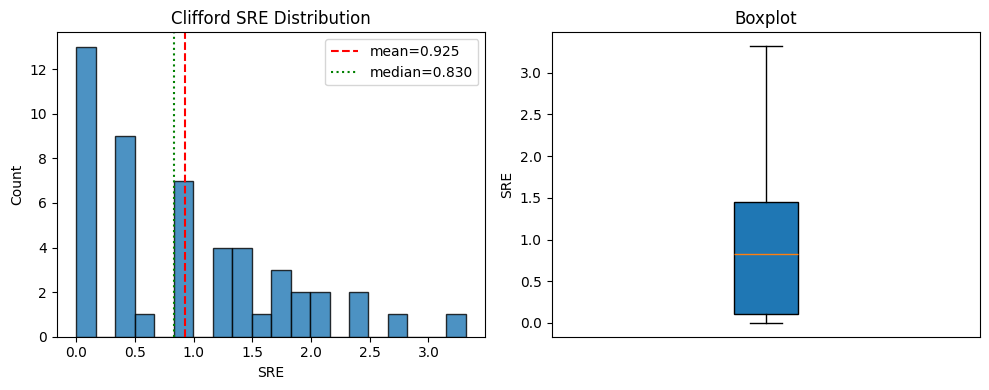

In [42]:
plot_sre_distribution(sre_values_cliff, bins=20, title="Clifford SRE Distribution")

### Haar-like

In [43]:
family = "haar"
backend = "pennylane"

In [44]:
family_cls = FAMILY_REGISTRY[family]
family_obj = family_cls()

In [45]:
sre_values_haar = []

for s in range(50):
    graph_data, gate_counts, controls, sre_value = generate_circuit(
        n_qubits=n_qubits,
        n_layers=n_layers,
        family=family,
        backend=backend,
        seed=int(s + rng.integers(0, 1_000_000)),
    )
    print(f"Sample {s} with {controls['sampling_regime']}: SRE={sre_value}")
    sre_values_haar.append(sre_value)

Sample 0 with sparse_weak: SRE=0.022684993078194146
Sample 1 with dense_weak: SRE=1.0248361845884133
Sample 2 with sparse_weak: SRE=0.12030510218508206


Sample 3 with full: SRE=5.9289871174981315
Sample 4 with none: SRE=-0.0
Sample 5 with sparse_full: SRE=2.5104779642830146
Sample 6 with full: SRE=5.761451349379808
Sample 7 with none: SRE=-0.0
Sample 8 with medium: SRE=1.5122529039660058
Sample 9 with sparse_full: SRE=3.4012780638772258
Sample 10 with dense_weak: SRE=0.06795366430991921
Sample 11 with dense_weak: SRE=1.1341899680746952
Sample 12 with dense_weak: SRE=0.21721930486619012
Sample 13 with sparse_weak: SRE=0.05796758036967136
Sample 14 with medium: SRE=3.7537247891324776
Sample 15 with sparse_weak: SRE=0.043541977751466836
Sample 16 with medium: SRE=3.2975887533844297
Sample 17 with sparse_full: SRE=3.947542952464224
Sample 18 with sparse_weak: SRE=0.03587266310514573
Sample 19 with none: SRE=-0.0
Sample 20 with sparse_weak: SRE=0.008475319959701568
Sample 21 with dense_weak: SRE=0.16459607755546404
Sample 22 with medium: SRE=3.1826610768546835
Sample 23 with sparse_full: SRE=1.478100456962947
Sample 24 with full: SRE=5.7259

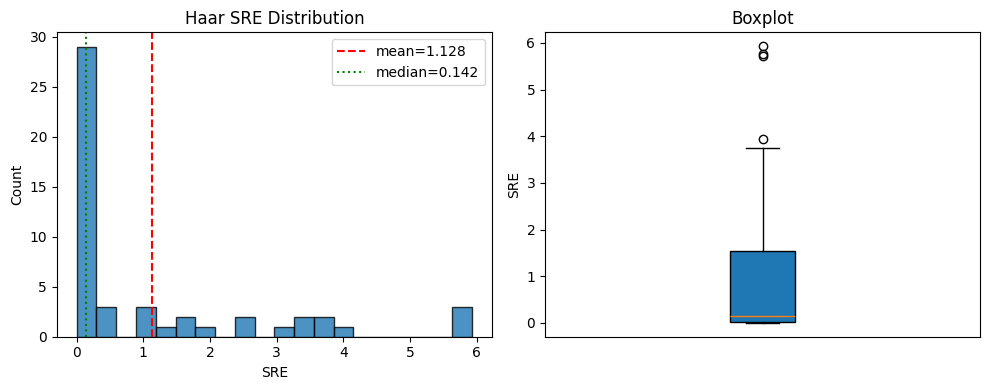

In [46]:
plot_sre_distribution(sre_values_haar, bins=20, title="Haar SRE Distribution")

### Random rotations

In [47]:
family = "random"
backend = "pennylane"

In [48]:
family_cls = FAMILY_REGISTRY[family]
family_obj = family_cls()

In [49]:
sre_values_random = []

for s in range(50):
    graph_data, gate_counts, controls, sre_value = generate_circuit(
        n_qubits=n_qubits,
        n_layers=n_layers,
        family=family,
        backend=backend,
        seed=int(s + rng.integers(0, 1_000_000)),
    )
    print(f"Sample {s} with {controls['sampling_regime']}: SRE={sre_value}")
    sre_values_random.append(sre_value)

Sample 0 with small_angles: SRE=1.904601167461848
Sample 1 with identity_like: SRE=0.0015694993646177542
Sample 2 with generic: SRE=4.459287258650482
Sample 3 with identity_like: SRE=0.0013960907938936732
Sample 4 with clifford_like: SRE=0.013497667600316076
Sample 5 with generic: SRE=4.153098955606506
Sample 6 with small_angles: SRE=1.6277436861079124
Sample 7 with clifford_like: SRE=0.006076188200847244
Sample 8 with generic: SRE=3.042264269401074
Sample 9 with generic: SRE=3.834498231730622
Sample 10 with small_angles: SRE=2.0827965538311015
Sample 11 with small_angles: SRE=1.6443325569287703
Sample 12 with small_angles: SRE=0.617185818180589
Sample 13 with generic: SRE=4.390951362423405
Sample 14 with clifford_like: SRE=0.010289206440873146
Sample 15 with identity_like: SRE=8.844357331075787e-05
Sample 16 with generic: SRE=3.3528172993134717
Sample 17 with generic: SRE=4.678605701976586
Sample 18 with generic: SRE=3.618244059052158
Sample 19 with generic: SRE=4.867377737337824
Samp

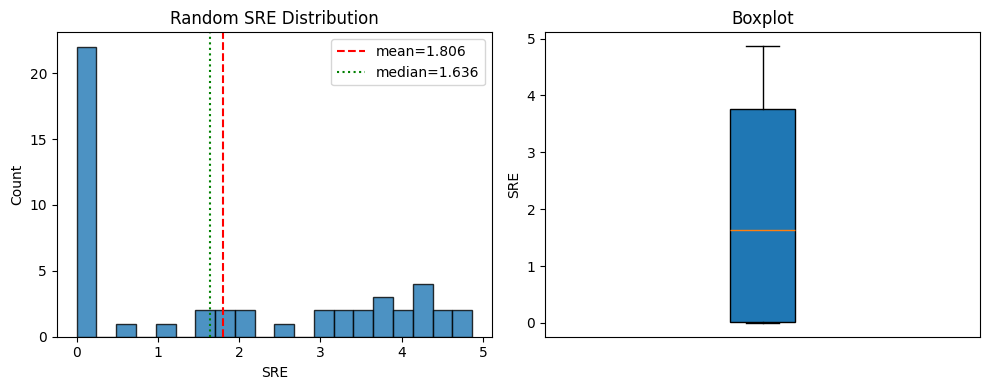

In [50]:
plot_sre_distribution(sre_values_random, bins=20, title="Random SRE Distribution")

### Quansistor

In [51]:
family = "quansistor"
backend = "pennylane"

In [52]:
family_cls = FAMILY_REGISTRY[family]
family_obj = family_cls()

In [53]:
sre_values_quansistor = []

for s in range(50):
    graph_data, gate_counts, controls, sre_value = generate_circuit(
        n_qubits=n_qubits,
        n_layers=n_layers,
        family=family,
        backend=backend,
        seed=int(s + rng.integers(0, 1_000_000)),
    )
    print(f"Sample {s} with {controls['sampling_regime']}: SRE={sre_value}")
    sre_values_quansistor.append(sre_value)

Sample 0 with structured_opposite_ab: SRE=2.848656447403906
Sample 1 with structured_opposite_ab: SRE=4.61049258050436
Sample 2 with identity_like: SRE=0.04347465757525124
Sample 3 with structured_equal_ab: SRE=4.497002556945203
Sample 4 with generic_uniform: SRE=5.680152688138073
Sample 5 with generic_uniform: SRE=5.881929737343964
Sample 6 with moderate: SRE=5.551259835627998
Sample 7 with weak: SRE=2.986278200182732
Sample 8 with moderate: SRE=5.266101197734515
Sample 9 with structured_equal_ab: SRE=3.994744583577756
Sample 10 with generic_uniform: SRE=5.762820256197989
Sample 11 with structured_equal_ab: SRE=2.865391688795359
Sample 12 with structured_opposite_ab: SRE=4.171639379906945
Sample 13 with moderate: SRE=4.456598770829793
Sample 14 with generic_uniform: SRE=5.537660108780337
Sample 15 with structured_opposite_ab: SRE=4.447042392496749
Sample 16 with moderate: SRE=4.475707203878852
Sample 17 with generic_uniform: SRE=5.336168294457009
Sample 18 with structured_opposite_ab:

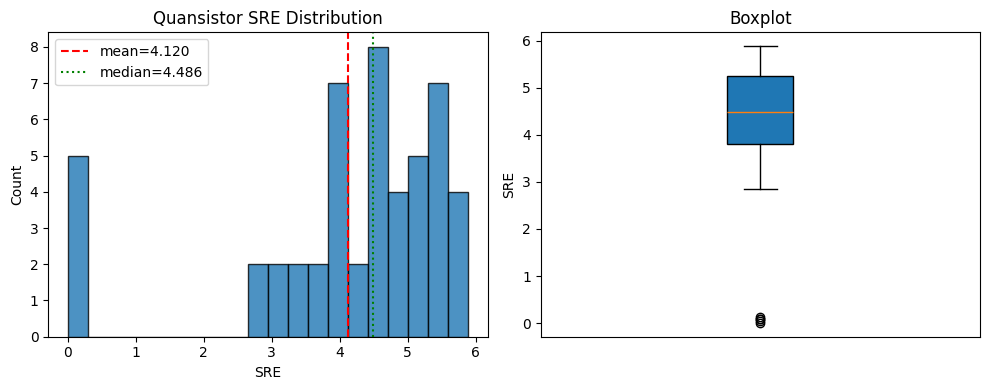

In [54]:
plot_sre_distribution(sre_values_quansistor, bins=20, title="Quansistor SRE Distribution")

## Quansistor parameters

In [55]:
def circ_X(a, b, g):
    """Creates a matrix of symmetry class X defined in section A of
    https://doi.org/10.1103/PhysRevA.106.062610.
    
    @param a: Parameter alpha defined in equation 18 of
    https://doi.org/10.1103/PhysRevA.106.062610.
    @param b: Parameter beta defined in equation 18 of
    https://doi.org/10.1103/PhysRevA.106.062610.
    @param g: Parameter gamma defined in equation 18 of
    https://doi.org/10.1103/PhysRevA.106.062610.

    @return: Matrix of symmetry class X.
    """
    # Matrix implementation in logical basis.
    # Obtained from Eqn.33 of paper.

    # Eigenvalues lambda_0,...,lambda_3. Note lambda_0=lambda_4 from paper.
    l0 = 2 * a + g
    l1 = -2 * b - g
    l2 = -2 * a + g
    l3 = 2 * b - g

    e0 = 0.25 * np.exp(-1.0j * l0)
    e1 = 0.25 * np.exp(-1.0j * l1)
    e2 = 0.25 * np.exp(-1.0j * l2)
    e3 = 0.25 * np.exp(-1.0j * l3)

    e11 = e0 + e1 + e2 + e3
    e12 = e0 - 1.0j * e1 - e2 + 1.0j * e3
    e13 = e0 - e1 + e2 - e3
    e14 = e0 + 1.0j * e1 - e2 - 1.0j * e3

    return np.array(
        [
            [e11, e12, e13, e14],
            [e14, e11, e12, e13],
            [e13, e14, e11, e12],
            [e12, e13, e14, e11],
        ],
    )


def circ_Y(a, b, g):
    """Creates a matrix of symmetry class Y defined in section B of
    https://doi.org/10.1103/PhysRevA.106.062610.
    
    @param a: Parameter alpha defined in equation 23 of
    https://doi.org/10.1103/PhysRevA.106.062610.
    @param b: Parameter beta defined in equation 23 of
    https://doi.org/10.1103/PhysRevA.106.062610.
    @param g: Parameter gamma defined in equation 23 of
    https://doi.org/10.1103/PhysRevA.106.062610.

    @return: Matrix of symmetry class Y.
    """
    # Matrix implementation in logical basis.
    # Obtained from Eqn.33 of paper.

    # Constants
    SQRT2 = np.sqrt(2)
    E_I_PI_OVER_4 = (1 + 1.0j) / SQRT2
    E_I_3_PI_OVER_4 = (-1 + 1.0j) / SQRT2

    # Eigenvalues lambda_0,...,lambda_3. Note lambda_0 = lambda_4 from paper.
    l0 = SQRT2 * a + SQRT2 * b + g
    l1 = SQRT2 * a - SQRT2 * b - g
    l2 = -SQRT2 * a - SQRT2 * b + g
    l3 = -SQRT2 * a + SQRT2 * b - g

    e0 = 0.25 * np.exp(-1.0j * l0)
    e1 = 0.25 * np.exp(-1.0j * l1)
    e2 = 0.25 * np.exp(-1.0j * l2)
    e3 = 0.25 * np.exp(-1.0j * l3)

    e11 = e0 + e1 + e2 + e3
    e12 = e0 - 1.0j * e1 - e2 + 1.0j * e3
    e13 = -e0 + e1 - e2 + e3
    e14 = e0 + 1.0j * e1 - e2 - 1.0j * e3
    e23a = (e0 - e2) * E_I_3_PI_OVER_4
    e23b = (e1 - e3) * E_I_PI_OVER_4
    e24 = e0 - e1 + e2 - e3
    e34a = -(e0 - e2) * E_I_PI_OVER_4
    e34b = -(e1 - e3) * E_I_3_PI_OVER_4

    return np.array(
        [
            [e11, E_I_PI_OVER_4 * e12, e13, E_I_PI_OVER_4 * e14],
            [-E_I_3_PI_OVER_4 * e14, e11, e23a + e23b, e24],
            [e13, e34a + e34b, e11, e34a - e34b],
            [-E_I_3_PI_OVER_4 * e12, e24, e23a - e23b, e11],
        ],
    )

In [56]:
a, b, g = 0.5, 1.0, 0.0
U_X = circ_X(a, b, g)
U_Y = circ_Y(a, b, g)

In [57]:
print("Unitary of symmetry class X:")
print(U_X)
print("Unitary of symmetry class Y:")
print(U_Y)

Unitary of symmetry class X:
[[ 0.06207773+0.j          0.45464871-0.42073549j  0.47822457+0.j
  -0.45464871-0.42073549j]
 [-0.45464871-0.42073549j  0.06207773+0.j          0.45464871-0.42073549j
   0.47822457+0.j        ]
 [ 0.47822457+0.j         -0.45464871-0.42073549j  0.06207773+0.j
   0.45464871-0.42073549j]
 [ 0.45464871-0.42073549j  0.47822457+0.j         -0.45464871-0.42073549j
   0.06207773+0.j        ]]
Unitary of symmetry class Y:
[[ 0.11855535+0.j          0.5309974 -0.07163471j  0.64168925+0.j
   0.07163471-0.5309974j ]
 [-0.5309974 -0.07163471j  0.11855535+0.j          0.07163471+0.5309974j
  -0.64168925+0.j        ]
 [ 0.64168925+0.j         -0.07163471+0.5309974j   0.11855535+0.j
  -0.5309974 +0.07163471j]
 [-0.07163471-0.5309974j  -0.64168925+0.j          0.5309974 +0.07163471j
   0.11855535+0.j        ]]


# Haar unitary

In [58]:
from scipy.linalg import expm

def haar_unitary_gate(d, rng):
    a, b = rng.normal(size=(d, d)), rng.normal(size=(d, d))

    Z = a + 1j * b
    Q, R = np.linalg.qr(Z)

    Lambda = np.diag([R[i, i] / np.abs(R[i, i]) for i in range(d)])
    return np.dot(Q, Lambda)

def random_hermitian(d: int, rng: np.random.Generator) -> np.ndarray:
    """Generates a random Hermitian matrix of dimension d x d."""
    A = rng.normal(size=(d, d)) + 1j * rng.normal(size=(d, d))
    h = A + A.conj().T
    norm = np.linalg.norm(h)
    return h / norm if norm > 0 else h

def haar_gate(d: int, rng: np.random.Generator, strength: float) -> np.ndarray:
    """Generates a Haar random unitary matrix of dimension d x d."""
    h = random_hermitian(d, rng)
    return expm(-1j * strength * h)


In [59]:
rng = np.random.default_rng(seed=123)

In [60]:
U_haar_QR = haar_unitary_gate(4, rng)
U_haar_exp = haar_gate(4, rng, strength=1.0)

In [61]:
print("Haar random unitary via QR decomposition:")
print(U_haar_QR)
print("Haar random unitary via matrix exponential:")
print(U_haar_exp)

Haar random unitary via QR decomposition:
[[-0.29436883+0.45594282j -0.20043555+0.10303879j  0.24265897+0.0355915j
   0.53747576+0.55284845j]
 [ 0.27386659-0.65695749j  0.12280601-0.04460506j  0.1215569 +0.43772439j
   0.48434669+0.18804942j]
 [-0.09422083+0.22462426j -0.31682859+0.31683618j -0.07212668+0.78013084j
  -0.08567888-0.34460644j]
 [ 0.35479624+0.11684647j -0.5433251 -0.66043167j  0.34191547+0.05252205j
  -0.07409614-0.06276449j]]
Haar random unitary via matrix exponential:
[[ 0.88854395-0.35179605j -0.02071222+0.245031j    0.08565806-0.08860763j
   0.09013331+0.05428969j]
 [ 0.16940016+0.1210531j   0.81238497-0.49389606j  0.16185886-0.04611354j
   0.04205965+0.15051021j]
 [-0.17037844+0.00722461j -0.10442948+0.10426052j  0.86424124-0.40930869j
   0.18566934-0.01495305j]
 [-0.06982218+0.09707098j  0.03733142+0.1116188j  -0.18789653+0.08206709j
   0.95608793+0.12532142j]]
